# Compas Analysis

What follows are the calculations performed for ProPublica's analysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
print(raw_data.shape[0])

7214


In [2]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [3]:
# Data Preparation for Modeling (COMPAS Dataset)

# Select relevant features for modeling
# These variables capture demographic attributes, criminal history,
# and COMPAS risk scores used in the analysis.
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# ── Filtering ────────────────────────────────────────────────────
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]
df = df.reset_index(drop=True)

# ── Type conversions ─────────────────────────────────────────────
for col in ["c_jail_in", "c_jail_out"]:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# ── Derived factors with reference levels ─────────────────────────
df["crime_factor"] = pd.Categorical(df["c_charge_degree"])

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Less than 25", "Greater than 45"]
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"]
)

df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"]
)

df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] != "Low", "HighScore", "LowScore"),
    categories=["LowScore", "HighScore"]
)

print(f"Number of observations after filtering: {len(df)}")

Number of observations after filtering: 6172


In [4]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
3,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
4,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [5]:
# Similar to glimpse(df) in R, but also shows null counts and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6172 entries, 0 to 6171
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   object             
 2   race                     6172 non-null   object             
 3   age_cat                  6172 non-null   object             
 4   score_text               6172 non-null   object             
 5   sex                      6172 non-null   object             
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   int64              
 10  two_year_recid           6172 non-null   int64              
 11  c_jail_in                6172 

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [6]:
# Feature Engineering: Length of Stay
df["length_of_stay"] = (
    df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()
).dt.days

# Exploratory Analysis: Relationship with Risk Score

corr = df[["length_of_stay", "decile_score"]].dropna().corr()

# Extract correlation coefficient
correlation_value = corr.loc["length_of_stay", "decile_score"]
print(correlation_value)


0.20732969161470416


After filtering we have the following demographic breakdown:

In [7]:
# This is equivalent to R's summary(df$age_cat).
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


Out of the original 7,214 records, 6,172 valid observations remained (~14.5% removed) after applying quality filters. The final sample is highly imbalanced in terms of race: 51.4% Black defendants vs. 34.1% White, which is already a relevant factor for bias interpretation.
A total of 45.5% of defendants recidivated within two years, establishing the model’s baseline. The gender distribution is 81% male and 19% female, and the dominant age group is 25–45 years.

In [8]:
# This is equivalent to R's summary(df$race)
df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [9]:
# Compute the percentage representation of each racial group
n_total = len(df)
races = [
    ("Black defendants",           "African-American"),
    ("White defendants",           "Caucasian"),
    ("Hispanic defendants",        "Hispanic"),
    ("Asian defendants",           "Asian"),
    ("Native American defendants", "Native American"),
]
for label, race in races:
    pct = (df["race"] == race).sum() / n_total * 100
    print(f"{label}: {pct:.2f}%")

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [10]:
# This is equivalent to R's summary(df$score_text)
print(df["score_text"].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [11]:
# This is equivalent to R's xtabs(~ sex + race, data=df)
print(pd.crosstab(df["sex"], df["race"]))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [12]:
# This is equivalent to R's summary(df$sex)
df["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


In [13]:
# Compute the percentage representation of each gender group
print("Men: %.2f%%"   % ((df["sex"] == "Male").sum()   / n_total * 100))
print("Women: %.2f%%" % ((df["sex"] == "Female").sum() / n_total * 100))

Men: 80.96%
Women: 19.04%


In [14]:
# This is equivalent to R's nrow(filter(df, two_year_recid == 1))
print((df["two_year_recid"] == 1).sum())

2809


In [15]:
# Compute the percentage of defendants who reoffended within
print((df["two_year_recid"] == 1).sum() / len(df) * 100)

45.51198963058976


**Data Composition and Potential Sources of Bias**
Out of the original 7,214 records, 6,172 valid observations remained (~14.5% removed) after applying quality filters. The final sample is highly imbalanced in terms of race: 51.4% Black defendants vs. 34.1% White, which is already a relevant factor for bias interpretation.
A total of 45.5% of defendants recidivated within two years, establishing the model’s baseline. The gender distribution is 81% male and 19% female, and the dominant age group is 25–45 years.

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

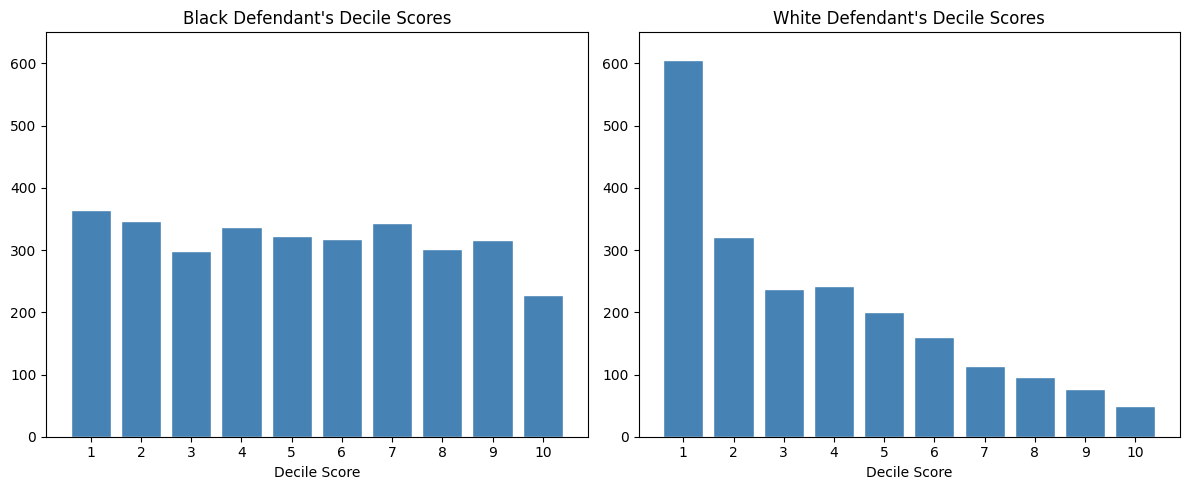

In [16]:
# Visualize the distribution of COMPAS decile scores separately
# for Black and White defendants
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, race, title in [
    (axes[0], "African-American", "Black Defendant's Decile Scores"),
    (axes[1], "Caucasian",        "White Defendant's Decile Scores"),
]:
    counts = (
        df[df["race"] == race]["decile_score"]
        .value_counts()
        .reindex(range(1, 11), fill_value=0)
        .sort_index()
    )
    ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white")
    ax.set_xlabel("Decile Score")
    ax.set_ylim(0, 650)
    ax.set_title(title)
    ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [17]:
# This is equivalent to R's  xtabs(~ decile_score + race, data=df)
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [18]:
# Modeling: Logistic Regression (Interpretable Model)

# Fit a logistic regression model to predict whether a defendant
# receives a high COMPAS risk score (HighScore vs LowScore).
# This mirrors glm(..., family = binomial(link = 'logit') in R.
# Dependent variable: binary risk score (0 = LowScore, 1 = HighScore)
df["score_binary"] = (df["score_text"] != "Low").astype(int)

model_glm = smf.logit(
    "score_binary ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        03:06:22   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.5255      0.079    -19.430  

**Model Fit and Evidence of Racial Bias**

The pseudo R² = 0.273 indicates a moderate model fit — the model captures a meaningful portion of the variation but is not perfect.

Key point: race is statistically significant (p < 0.001) even after controlling for prior offenses and actual recidivism. This suggests evidence of bias, not merely differences in criminal history.

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [19]:
# Model Interpretation: Relative Risk by Race

# Compute the relative risk of being classified as high risk
# for African-American defendants compared to Caucasian defendants.
# This is derived from the logistic regression coefficients.

intercept = model_glm.params["Intercept"]
coef_race  = model_glm.params["race_factor[T.African-American]"]

control = np.exp(intercept) / (1 + np.exp(intercept))
relative_risk_race = np.exp(coef_race) / (1 - control + control * np.exp(coef_race))
print(f"Relative risk (African-American vs Caucasian): {relative_risk_race:.6f}")

Relative risk (African-American vs Caucasian): 1.452837


Women are 19.4% more likely than men to get a higher score.

In [20]:
# Model Interpretation: Relative Risk by Gender

# Compute the relative risk of being classified as high risk
# for Female defendants compared to Male defendants.
coef_gender = model_glm.params["gender_factor[T.Female]"]
relative_risk_gender = np.exp(coef_gender) / (1 - control + control * np.exp(coef_gender))
print(f"Relative risk (Female vs Male): {relative_risk_gender:.6f}")

Relative risk (Female vs Male): 1.194795


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [21]:
# Model Interpretation: Relative Risk by Age

# Compute the relative risk of being classified as high risk
# for defendants younger than 25 compared to the reference group (25–45).
coef_age = model_glm.params["age_factor[T.Less than 25]"]
relative_risk_age = np.exp(coef_age) / (1 - control + control * np.exp(coef_age))
print(f"Relative risk (Less than 25 vs 25-45): {relative_risk_age:.6f}")

Relative risk (Less than 25 vs 25-45): 2.496120


In [22]:
# Model Predictions

df["pred_prob"]  = model_glm.predict(df)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")

In [23]:
# Model Evaluation: Overall Confusion Matrix
print("\n── Overall Confusion Matrix ──────────────────────────────────────────")

overall_cm = pd.crosstab(
    pd.Categorical(df["pred_class"], categories=["No Recid", "Recid"]),
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)
print(overall_cm)

TP = overall_cm.loc["Recid",    1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid",    0]
FN = overall_cm.loc["No Recid", 1]
n  = overall_cm.values.sum()

print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [24]:
# Model Evaluation: Confusion Matrix by Race

print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────")

def race_metrics_fn(group):
    actual = group["two_year_recid"].astype(int)
    pred   = (group["pred_class"] == "Recid").astype(int)
    TP = int(((pred == 1) & (actual == 1)).sum())
    TN = int(((pred == 0) & (actual == 0)).sum())
    FP = int(((pred == 1) & (actual == 0)).sum())
    FN = int(((pred == 0) & (actual == 1)).sum())
    n  = len(group)
    return pd.Series({
        "n":         n,
        "TP":        TP,
        "TN":        TN,
        "FP":        FP,
        "FN":        FN,
        "Accuracy":  round((TP + TN) / n,           3),
        "Precision": round(TP / (TP + FP),           3) if (TP + FP) > 0 else float("nan"),
        "Recall":    round(TP / (TP + FN),           3) if (TP + FN) > 0 else float("nan"),
        "FPR":       round(FP / (FP + TN),           3) if (FP + TN) > 0 else float("nan"),
        "FNR":       round(FN / (FN + TP),           3) if (FN + TP) > 0 else float("nan"),
    })

race_metrics = (
    df.groupby("race", observed=True)
      .apply(race_metrics_fn)
      .reset_index()
      .sort_values("n", ascending=False)
      .reset_index(drop=True)
)
print(race_metrics.to_string(index=False))



── Confusion Matrix by Race ──────────────────────────────────────────
            race      n     TP     TN    FP    FN  Accuracy  Precision  Recall   FPR   FNR
African-American 3175.0 1373.0  959.0 555.0 288.0     0.734      0.712   0.827 0.367 0.173
       Caucasian 2103.0  381.0 1148.0 133.0 441.0     0.727      0.741   0.464 0.104 0.536
        Hispanic  509.0   81.0  306.0  14.0 108.0     0.760      0.853   0.429 0.044 0.571
           Other  343.0   22.0  216.0   3.0 102.0     0.694      0.880   0.177 0.014 0.823
           Asian   31.0    2.0   22.0   1.0   6.0     0.774      0.667   0.250 0.043 0.750
 Native American   11.0    5.0    2.0   4.0   0.0     0.636      0.556   1.000 0.667 0.000


In [25]:
# Fairness Analysis: FPR and FNR Disparity by Race

print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────")

caucasian_row = race_metrics[race_metrics["race"] == "Caucasian"].iloc[0]
ref_fpr = caucasian_row["FPR"]
ref_fnr = caucasian_row["FNR"]

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = (disparity["FPR"] - ref_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - ref_fnr).round(3)

print(disparity.to_string(index=False))



── FPR and FNR Disparity by Race ─────────────────────────────────────
            race      n   FPR   FNR  delta_FPR  delta_FNR
African-American 3175.0 0.367 0.173      0.263     -0.363
       Caucasian 2103.0 0.104 0.536      0.000      0.000
        Hispanic  509.0 0.044 0.571     -0.060      0.035
           Other  343.0 0.014 0.823     -0.090      0.287
           Asian   31.0 0.043 0.750     -0.061      0.214
 Native American   11.0 0.667 0.000      0.563     -0.536


**Fairness Interpretation**

The model shows disparities in false positive and false negative rates across racial groups.

A higher false positive rate for Black defendants implies that they are more likely to be incorrectly classified as high risk, which can lead to harsher outcomes.

This raises an important governance question:
Which type of error is more harmful, and for whom?

This demonstrates that optimizing accuracy alone does not guarantee fair or equitable outcomes.

## **Conclusion**

The analysis empirically confirms that COMPAS is not a neutral predictor: it incorporates racial and age biases that are not fully explained by criminal history.

From a Responsible Machine Learning perspective, this represents a case of proxy discrimination, where race acts as an independent influential variable, violating fairness principles such as Equalized Odds (which would require equal FPR and FNR across groups).

The model optimizes overall accuracy at the expense of disproportionately impacting minority groups.

# Individual Homework 2
**Coding: Explaining the COMPAS Replacement Model**

In [26]:
# STEP 0 — Define features + Train/test split

from sklearn.model_selection import train_test_split

# Define features
numeric_features  = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
category_features = ["age_cat", "sex", "race", "c_charge_degree", "score_text"]
target            = "two_year_recid"
features          = numeric_features + category_features

X = df[features]
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 9), Test: (1235, 9)


In [27]:
# STEP 1 — Fit Logistic Regression and Gradient-Boosted Tree

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
])

# Logistic regression (GLM — interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200, max_depth=4, random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'days_b_screening_arrest',
                                                   'decile_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_cat', 'sex', 'race',
                                                   'c_charge_degree',
                                                   'score_text'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [28]:
# STEP 2 — Compare model performance by race
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"]    = y.values
    X_["pred"]      = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]
    for group, gdf in X_.groupby(group_col):
        cm = confusion_matrix(gdf["actual"], gdf["pred"], labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        results.append({
            "race":     group,
            "n":        len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR":      round(fp / (fp + tn), 3) if (fp + tn) > 0 else float("nan"),
            "FNR":      round(fn / (fn + tp), 3) if (fn + tp) > 0 else float("nan"),
            "AUC":      round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print("Logistic Regression")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\nGradient-Boosted Tree")
print(group_metrics(gbt_pipeline, X_test, y_test))

Logistic Regression
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.691  0.296  0.320  0.758
2         Caucasian  427     0.696  0.128  0.596  0.696
3          Hispanic   94     0.617  0.122  0.667  0.598
5             Other   65     0.785  0.064  0.611  0.789
1             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000    NaN    NaN

Gradient-Boosted Tree
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.690  0.322  0.300  0.744
2         Caucasian  427     0.710  0.143  0.534  0.714
3          Hispanic   94     0.660  0.122  0.578  0.648
5             Other   65     0.723  0.106  0.722  0.746
1             Asian    7     0.857  0.000  1.000  0.833
4   Native American    1     1.000  0.000    NaN    NaN


# 1. Compute SHAP values for your model on the test set. Produce: (a) a beeswarm summary plot, (b) a waterfall plot for the highest-risk and lowest-risk defendant in each racial group.

 92%|==================  | 1136/1235 [00:12<00:01]       

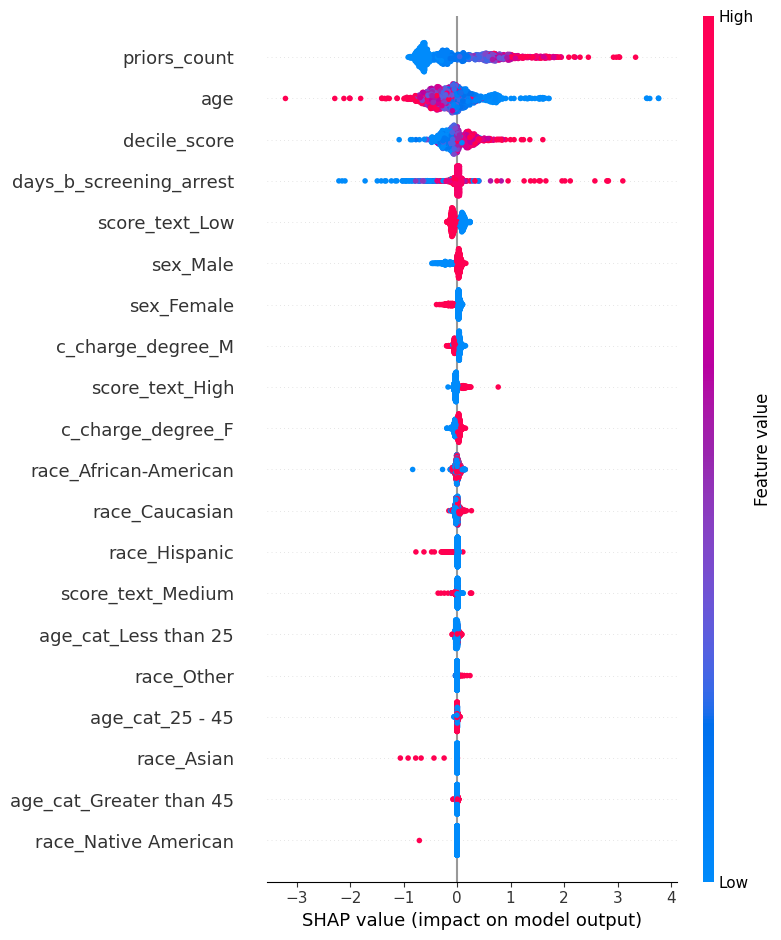

In [29]:
# STEP 4 — SHAP: Beeswarm
##!pip install shap
import shap

# Feature names after encoding
feat_names = (
    numeric_features +
    list(preprocessor.named_transformers_["cat"]
         .get_feature_names_out(category_features))
)

X_test_enc = preprocessor.transform(X_test)

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)
shap_values = explainer_shap(X_test_enc, check_additivity=False)

# (a) Global beeswarm summary plot
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)

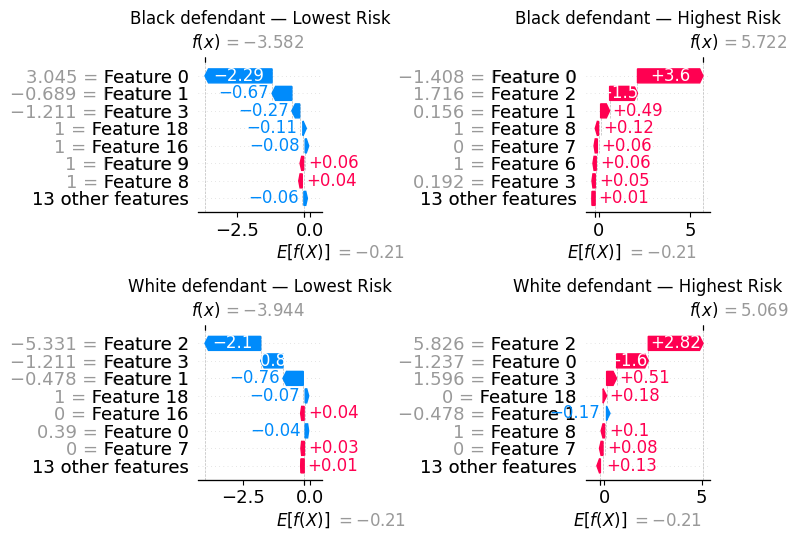

In [30]:
# STEP 4 — Waterfall for 4 individuals
# (b) Waterfall plots for the 4 individuals (homework requirement)
# Predicted probabilities on test set
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

# Select the 4 individuals required by the homework:
# highest-risk and lowest-risk defendant in each racial group
black_subset = X_test_copy[X_test_copy["race"] == "African-American"].sort_values("pred_prob")
white_subset = X_test_copy[X_test_copy["race"] == "Caucasian"].sort_values("pred_prob")

black_low_idx  = black_subset.index[0]            # lowest risk Black
black_high_idx = black_subset.index[-1]           # highest risk Black
white_low_idx  = white_subset.index[0]            # lowest risk White
white_high_idx = white_subset.index[-1]           # highest risk White

individuals = [
    ("Black defendant — Lowest Risk",  black_low_idx),
    ("Black defendant — Highest Risk", black_high_idx),
    ("White defendant — Lowest Risk",  white_low_idx),
    ("White defendant — Highest Risk", white_high_idx),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (label, idx) in zip(axes, individuals):
    loc = X_test.index.get_loc(idx)
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc], max_display=8, show=False)
    ax.set_title(label)


plt.tight_layout()
plt.show()

#2. Run LIME on the same four individuals. Compare LIME and SHAP feature attributions. Where do they agree? Where do they diverge?What does divergence imply for governance?


In [31]:
# STEP 3 — LIME: 4 individuals (highest/lowest risk per racial group)
# Select the 4 individuals required by the homework: highest-risk and lowest-risk defendant in each racial group
!pip install lime
from lime.lime_tabular import LimeTabularExplainer

X_train_enc = preprocessor.fit_transform(X_train)



# Build LIME explainer
explainer = LimeTabularExplainer(
    training_data         = X_train_enc,
    feature_names         = feat_names,
    class_names           = ["NoRecid", "Recid"],
    mode                  = "classification",
    discretize_continuous = True,
    random_state          = 42
)





In [32]:
# Store median-risk indices for DiCE (Step 5)
black_idx = black_subset.index[len(black_subset) // 2]
white_idx = white_subset.index[len(white_subset) // 2]

# Generate LIME explanations for all 4 individuals
individuals = [
    ("Black defendant — Lowest Risk",  black_low_idx),
    ("Black defendant — Highest Risk", black_high_idx),
    ("White defendant — Lowest Risk",  white_low_idx),
    ("White defendant — Highest Risk", white_high_idx),
]

for label, idx in individuals:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
        data_row   = row_enc[0],
        predict_fn = gbt_pipeline["classifier"].predict_proba,
        num_features = 6
    )
    prob = X_test_prob[X_test.index.get_loc(idx)]
    print(f"\nLIME: {label}  |  Predicted probability: {prob:.3f}")
    for feat, weight in exp.as_list():
        print(f"  {feat:<45}  {weight:+.4f}")


LIME: Black defendant — Lowest Risk  |  Predicted probability: 0.027
  days_b_screening_arrest <= 0.15                -0.3395
  age > 0.56                                     -0.1247
  0.00 < score_text_Low <= 1.00                  -0.0480
  decile_score <= -0.86                          -0.0422
  priors_count <= -0.69                          -0.0403
  0.00 < c_charge_degree_M <= 1.00               -0.0222

LIME: Black defendant — Highest Risk  |  Predicted probability: 0.997
  days_b_screening_arrest > 0.15                 +0.3438
  age <= -0.81                                   +0.1389
  score_text_Low <= 0.00                         +0.0475
  -0.48 < priors_count <= 0.16                   -0.0475
  sex_Female <= 0.00                             +0.0399
  score_text_High <= 0.00                        -0.0308

LIME: White defendant — Lowest Risk  |  Predicted probability: 0.019
  days_b_screening_arrest <= 0.15                -0.3378
  -0.69 < priors_count <= -0.48                 

LIME and SHAP agree in identifying the most influential features in the model, such as criminal history (*priors_count*), age (*age*), decile score (*decile_score*), and the number of days elapsed between arrest and assessment (*days_b_screening_arrest*). They also agree on the direction of these effects: these features steer predictions toward higher risk in some cases and toward lower risk in others, indicating consistency in the model's overall logic.

However, they diverge in the way they attribute and present these contributions. SHAP offers a more stable and consistent global view, capturing aggregated patterns across the entire dataset. Conversely, LIME generates local explanations that may vary depending on the specific individual being analyzed, which can alter the ranking or the magnitude of feature importance. This difference is particularly relevant for sensitive variables, such as race. This implies that the interpretation of the model is not singular and depends on the specific explanation method employed.

From a governance perspective, this means that relying on a single explainability technique is insufficient to fully understand the model's behavior. Both global and local explanations are necessary, given that a model may appear equitable on average yet still generate problematic outcomes for specific individuals. For this reason, a robust evaluation must be conducted—combining multiple interpretability approaches with fairness metrics—in order to ensure a defensible model.

#3. Generate at least one counterfactual per individual using DiCE (Python) or NICE (R). Report the minimal feature changes required to flip the prediction. Flag any counterfactuals that require changes to immutable features (race, sex)

In [33]:
# STEP 5 — Counterfactuals with DiCE (4 individuals + immutable flag)

!pip install dice-ml -q
import dice_ml
from dice_ml import Dice

IMMUTABLE = {"race", "sex"}   # features that cannot change in reality

dice_data = dice_ml.Data(
    dataframe           = pd.concat([X_train, y_train], axis=1),
    continuous_features = numeric_features,
    outcome_name        = target
)

dice_model = dice_ml.Model(
    model      = gbt_pipeline,
    backend    = "sklearn",
    model_type = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

# Run counterfactuals for all 4 individuals
for label, idx in individuals:
    query = X_test.loc[[idx]]
    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs        = 3,
        desired_class    = "opposite",
        permitted_range  = {
            "age":          [18, 70],
            "priors_count": [0, 38]
        },
        features_to_vary = ["age", "priors_count", "c_charge_degree"]
    )
    print(f"\nDiCE Counterfactuals: {label}")
    cf_df = cf.cf_examples_list[0].final_cfs_df

    # Flag immutable features if they changed
    immutable_changed = []
    for feat in IMMUTABLE:
        if feat in cf_df.columns:
            original_val = query[feat].values[0]
            if (cf_df[feat] != original_val).any():
                immutable_changed.append(feat)

    if immutable_changed:
        print(f"*Counterfactual requires change in immutable feature (race, sex): {immutable_changed}")
    else:
        print(f"*No immutable features changed")

    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  3.03it/s]


DiCE Counterfactuals: Black defendant — Lowest Risk
*No immutable features changed
Query instance (original outcome : 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,70,0,-1.0,1,Greater than 45,Male,African-American,M,Low,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,26,37,-,-,-,-,-,-,-,1
1,67,11,-,-,-,-,-,-,-,1
2,52,34,-,-,-,-,-,-,-,1


...

100%|██████████| 1/1 [00:00<00:00,  3.95it/s]


DiCE Counterfactuals: White defendant — Highest Risk
*No immutable features changed
Query instance (original outcome : 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,20,1,28.0,9,Less than 25,Male,Caucasian,F,High,1



Diverse Counterfactual set (new outcome: 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,57,4,-,-,-,-,-,-,-,0
1,60,-,-,-,-,-,-,M,-,0
2,54,3,-,-,-,-,-,-,-,0


DiCE counterfactuals reveal that flipping the prediction requires changes only in mutable features, primarily age and priors_count, and no counterfactual required modifications to immutable features such as race or sex.

# 4. Write a 300-word governance memo addressed to a hypothetical court auditor: summarise what your explanations reveal about model behaviour, any limitations of the methods, and what further monitoring you recommend.

##**Governance Memo - Model Audit Assessment**

This memorandum summarizes the analysis conducted on the COMPAS-based model using SHAP, LIME, and DiCE counterfactuals, focusing on the model's behavior, the limitations of these methods, and recommendations for their monitoring.
The results indicate that the model relies primarily on *days_b_screening_arrest*, *age*, and *priors_count*. Both SHAP and LIME consistently identify these key variables and agree on the direction of their impact: younger defendants with more prior offenses consistently receive higher risk scores. DiCE counterfactuals reinforce this finding: for both the high-risk Black defendant and the high-risk White defendant, increasing their age to approximately 69–70 years was sufficient to flip the prediction to low risk, suggesting that the model treats youth as an almost decisive risk factor. Regarding race, the SHAP beeswarm plot reveals a subtle yet discernible positive attribution for *race_African-American*, meaning that belonging to this group increases the predicted risk even after controlling for other variables. LIME also reflects race-related variables in its local explanations, suggesting that the model may be capturing indirect racial effects through correlated variables.
From an equity perspective, significant differences in false positive rates are observed across groups, particularly among African American defendants—implying that certain groups have been incorrectly classified as high risk.
It is worth noting that SHAP and LIME have limitations, as neither offers a single, definitive explanation of the model; furthermore, their results depend on the specific manner in which they are applied.
For this reason, it is recommended to combine global and local explanation methods with disaggregated equity metrics that monitor false positive and false negative rates across racial and age groups. Audits should be conducted quarterly, with automated alerts triggered whenever SHAP and LIME yield significantly different results for the same individual. Additionally, any defendant under the age of 25 classified as high-risk must undergo mandatory human review, given the disproportionate impact by age demonstrated by the model.
